# Table of Contents

- [Notebook Overview](#notebook-overview)
- [Import Libraries](#import-libraries)
- [Test Tetris Environment](#test-tetris-environment)
- [Crop and Normalize Observations](#crop-and-normalize-observations)
- [Build Tetris Environment](#build-tetris-environment)
- [Neural Network and Optimizer Setup](#neural-network-and-optimizer-setup)
- [Replay Buffer Initialization](#replay-buffer-initialization)
- [Epsilon Decay and Exploration Functions](#epsilon-decay-and-exploration-functions)
- [Softmax Exploration Policy](#softmax-exploration-policy)
- [Evaluation Function](#evaluation-function)
- [DQN Optimization Step](#dqn-optimization-step)
- [DQN Training Loop](#dqn-training-loop)
- [State and Replay Buffer Inspection](#state-and-replay-buffer-inspection)
- [DQN Training Parameters and Execution](#dqn-training-parameters-and-execution)
- [Plot Epsilon Decay](#plot-epsilon-decay)
- [Show Policy in Action](#show-policy-in-action)
- [Comparison: Parameter Decay Schedules](#comparison-parameter-decay-schedules)
- [Comparison: Learning Curves](#comparison-learning-curves)
- [Detailed Metric Comparison](#detailed-metric-comparison)
- [Summary Statistics & Analysis](#summary-statistics--analysis)
- [Qualitative Analysis: Why Softmax Won in This Run](#qualitative-analysis-why-softmax-won-in-this-run)
- [Save Best Games: Epsilon-Greedy vs Softmax](#save-best-games-epsilon-greedy-vs-softmax)

# Notebook Overview
This notebook trains a Deep Q-Network (DQN) agent on Atari Tetris using PyTorch and Gymnasium.

The workflow includes:
- environment preprocessing and custom reward shaping
- model training with replay memory and target networks
- comparison between **epsilon-greedy** and **softmax (Boltzmann)** exploration
- qualitative and quantitative evaluation of both strategies

# Import Libraries
This section imports the core dependencies used throughout the notebook:
- `numpy` for numerical operations
- `gymnasium` and `ale_py` for Atari Tetris
- `torch` for neural-network modeling and optimization

Keeping imports explicit makes the pipeline easier to read and reproduce.

In [1]:
import numpy as np
import gymnasium as gym
import ale_py
import torch

# Test Tetris Environment
This quick sanity check creates the Tetris environment, executes one random action, and verifies reset behavior.

Purpose:
- confirm that ALE/Gym integration is working
- verify that `step` and `reset` return expected values
- catch setup issues early before long training runs

In [ ]:
gym.register_envs(ale_py)

env = gym.make("ALE/Tetris-v5", render_mode="human", frameskip=4)
env.reset()
for _ in range(1):
    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        obs, info = env.reset()

env.close()

# Crop and Normalize Observations
This stage introduces a custom observation wrapper that standardizes the visual input before training.

**Detailed preprocessing analysis**

- **Cropping objective**: keep only the spatial region that is relevant for decision making (mainly the playable board) and discard low-value pixels such as HUD regions.
- **Shape handling**: the wrapper supports both grayscale `(H, W)` and multi-channel `(H, W, C)` observations and updates `observation_space` accordingly.
- **Normalization policy**: outputs are consistently mapped to float values in `[0, 1]`, either by preserving already scaled input or dividing raw pixel values by `255.0`.
- **Training impact**: this reduces input variance, improves optimization stability, and makes gradient updates less sensitive to raw pixel scale.

In practice, this wrapper reduces noise in the state representation and provides cleaner inputs to downstream convolutional layers.

In [ ]:
class CropObservation(gym.ObservationWrapper):
    def __init__(self, env, top=0, bottom=None, left=0, right=None):
        super().__init__(env)
        self.top, self.bottom, self.left, self.right = top, bottom, left, right

        h, w = self.observation_space.shape[:2]
        b = h if bottom is None else bottom
        r = w if right is None else right

        new_h = b - top
        new_w = r - left

        # Keep channels when present (grayscale -> (H,W); RGB -> (H,W,3)).
        if len(self.observation_space.shape) == 2:
            self.observation_space = gym.spaces.Box(0, 1, shape=(new_h, new_w), dtype=np.float32)
        else:
            c = self.observation_space.shape[2]
            self.observation_space = gym.spaces.Box(0, 1, shape=(new_h, new_w, c), dtype=np.float32)

    def observation(self, obs):
        # Always normalize to [0, 1] for consistent network input.
        cropped = obs[self.top:self.bottom, self.left:self.right]
        return cropped.astype(np.float32) / 255.0 if cropped.max() > 1.0 else cropped.astype(np.float32)


# Build Tetris Environment
This section defines the full environment pipeline used for training. The environment is not used in its default form: it is progressively transformed to improve learning signal quality and sample efficiency.

**Detailed environment analysis**

1. **Base Atari environment creation**
   - The environment is created with `gym.make(env_name, render_mode=mode)` and seeded for reproducibility.
   - Action-space seeding is also applied to keep exploration behavior consistent across runs.

2. **Atari preprocessing**
   - `AtariPreprocessing` is configured with `frame_skip=1` to avoid hidden extra skipping and keep control explicit.
   - `screen_size=128` preserves more visual detail than smaller settings.
   - `grayscale_obs=True` reduces channel complexity from RGB to one channel.
   - `scale_obs=True` scales observations, helping numerical stability in the neural network.

3. **Spatial cropping (playfield focus)**
   - `CropObservation(top=0, bottom=128, left=0, right=64)` removes most HUD and keeps the board area.
   - This reduces irrelevant pixels and directs the model toward actionable game state information.

4. **Custom reward shaping (`LinesReward`)**
   - The original reward is replaced by a shaped reward designed to better reflect useful Tetris behavior.
   - A line-clear bonus is applied with increasing weight by cleared lines:
     - 0 lines: `0.0`
     - 1 line: `line_bonus`
     - 2 lines: `2.5 * line_bonus`
     - 3 lines: `4.0 * line_bonus`
     - 4 lines: `7.0 * line_bonus`
   - A terminal penalty (`fail_penalty`) is applied on true failure states.
   - A small per-step penalty (`step_penalty`) is used to discourage passive or inefficient play.
   - Practical effect: reward density increases, learning feedback becomes less sparse, and policy updates become more informative earlier in training.

5. **Post-wrapper normalization safety**
   - `NormalizeObs` ensures observations remain in a consistent numeric range even if upstream settings differ.
   - This prevents scale mismatch across wrappers and keeps model input stable.

6. **Frame stacking (temporal context)**
   - Four consecutive frames are stacked with `FrameStackObservation(env, 4)`.
   - This allows the agent to infer motion, piece transitions, and short-term dynamics from static inputs.

**Why this environment design matters**

This pipeline intentionally balances **state simplification** (grayscale + crop), **temporal information** (frame stack), and **learning signal engineering** (custom reward shaping). In Tetris, sparse rewards and delayed consequences are major optimization challenges; the custom shaped reward addresses this by providing more frequent and behavior-aligned feedback during training while still encouraging long-term survival and line-clearing performance.

In [ ]:
def make_tetris_env(env_name, mode="rgb_array", seed=42):
    env = gym.make(env_name, render_mode=mode)
    env.reset(seed=seed)
    env.action_space.seed(seed)

    env = gym.wrappers.AtariPreprocessing(
        env,
        noop_max=0,
        frame_skip=1,
        screen_size=128,     # larger screen
        grayscale_obs=True,
        scale_obs=True
    )

    # Crop to keep the playfield and remove most HUD pixels.
    env = CropObservation(env, top=0, bottom=128, left=0, right=64)

    # Reward shaping wrapper with line-clear bonuses and terminal penalty.
    class LinesReward(gym.Wrapper):
        def __init__(self, env, fail_penalty=1.0, line_bonus=5.0, step_penalty=0.01):
            super().__init__(env)
            self.fail_penalty = fail_penalty
            self.line_bonus = line_bonus
            self.step_penalty = step_penalty
        def step(self, action):
            obs, orig_reward, term, trunc, info = self.env.step(action)
            lines = int(info.get("lines_cleared", 0))
            r = {0: 0.0, 1: self.line_bonus, 2: 2.5*self.line_bonus, 3: 4.0*self.line_bonus, 4: 7.0*self.line_bonus}.get(lines, 0.0)
            if term and not trunc:
                r -= self.fail_penalty
            r -= self.step_penalty
            return obs, float(r), term, trunc, info
    env = LinesReward(env, fail_penalty=1.0, line_bonus=5.0, step_penalty=0.01)

    # Explicit normalization (scale_obs=True already applies scaling, kept for robustness).
    class NormalizeObs(gym.ObservationWrapper):
        def __init__(self, env):
            super().__init__(env)
            self.observation_space = env.observation_space
        def observation(self, obs):
            return obs.astype(np.float32) / 1.0 if obs.max() <= 1.0 else obs.astype(np.float32) / 255.0
    env = NormalizeObs(env)

    # Stack four frames to provide short-term temporal context.
    try:
        env = gym.wrappers.FrameStackObservation(env, 4, stack_dim=0)
    except TypeError:
        env = gym.wrappers.FrameStackObservation(env, 4)

    return env

seed = 42
env_name = "ALE/Tetris-v5"
tetris = make_tetris_env(env_name, seed=seed)


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


# Neural Network and Optimizer Setup
This section defines the Q-network architecture and optimization components used by DQN.

Design choices:
- convolutional layers extract spatial patterns from stacked game frames
- fully connected layers map features to action values
- dropout reduces overfitting risk
- RMSprop is used for stable optimization in value-based RL

In [ ]:

torch.manual_seed(seed)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

def create_network(input_shape, n_actions):
    c, h, w = input_shape
    conv = torch.nn.Sequential(
        torch.nn.Conv2d(c, 32, 8, 4), torch.nn.ReLU(),
        torch.nn.Conv2d(32, 64, 4, 2), torch.nn.ReLU(),
        torch.nn.Conv2d(64, 64, 3, 1), torch.nn.ReLU(),
        torch.nn.Flatten(),
    )

    with torch.no_grad():
        n = conv(torch.zeros(1, c, h, w)).shape[1]

    net = torch.nn.Sequential(
        conv,
        torch.nn.Linear(n, 512), torch.nn.ReLU(),
        torch.nn.Dropout(p=0.3),  # Dropout helps reduce overfitting during training.
        torch.nn.Linear(512, n_actions),
    )
    return net.to(device)

def set_optimizer(model, lr, momentum=0.95, eps=0.01, alpha=0.99):
    return torch.optim.RMSprop(model.parameters(), lr=lr, momentum=momentum, eps=eps, alpha=alpha)

def update_target(target_model, online_model):
    target_model.load_state_dict(online_model.state_dict())

@torch.no_grad()
def pi(state, online_q):
    x = torch.from_numpy(np.asarray(state)).unsqueeze(0).to(device)
    return int(torch.argmax(online_q(x)).cpu().item())

state_size  = tetris.observation_space.shape
action_size = tetris.action_space.n

dnn_online = create_network(state_size, action_size)
dnn_target = create_network(state_size, action_size)

learning_rate = 5e-4
optimizer_online = set_optimizer(dnn_online, learning_rate)


Using device: mps


# Replay Buffer Initialization
This section initializes replay memory for off-policy learning.

Why replay memory matters:
- stores transitions `(state, action, reward, next_state, done)`
- enables random mini-batch sampling
- reduces correlation between consecutive samples
- improves training stability and sample efficiency

In [ ]:
# Replay buffer capacity.
replay_memory_size = 30000

# Experience tuple structure.
experience_type = np.dtype([
    ('state',       np.float32, state_size),
    ('action',      np.int32),
    ('reward',      np.float32),
    ('next_state',  np.float32, state_size),
    ('failure',     np.int8)
 ])

# Replay memory initialization.
replay_memory = dict(
    size    = replay_memory_size,
    buffer  = np.empty(replay_memory_size, dtype=experience_type),
    index   = 0,
    entries = 0
)

def store_experience(mem, *exp):
    exp = exp[0] if len(exp) == 1 else exp  # Support both a single tuple and separate fields.
    mem['buffer'][mem['index']] = exp
    mem['entries'] = min(mem['entries'] + 1, mem['size'])
    mem['index'] = (mem['index'] + 1) % mem['size']



def sample_experiences(mem, batch_size):
    idx = np.random.choice(mem['entries'], batch_size, replace=False)
    return mem['buffer'][idx]


# Epsilon Decay and Exploration Functions
This section implements epsilon-greedy exploration and a decay schedule for epsilon.

Behavior over time:
- early training: high epsilon encourages broad exploration
- late training: low epsilon favors exploitation of learned Q-values

A controlled exploration schedule is essential to avoid poor local optima.

In [6]:
import random

def decay_epsilon(eps_max, eps_min, steps):
    v = np.logspace(0, -2, steps, base=10)
    v = (v - v.min()) / (v.max() - v.min())
    return (eps_max - eps_min) * v + eps_min

@torch.no_grad()
def epsilon_greedy(dnn, state, action_size, epsilon):
    if random.random() < epsilon:
        return np.random.randint(action_size)

    x = torch.from_numpy(np.asarray(state)).unsqueeze(0).to(device)
    return int(torch.argmax(dnn(x)).cpu().item())


# Softmax Exploration Policy
This section defines softmax (Boltzmann) exploration as an alternative to epsilon-greedy.

Key idea:
- actions are sampled from a probability distribution derived from Q-values
- temperature `tau` controls randomness
- high `tau` encourages exploration, low `tau` approaches greedy behavior

This strategy can produce smoother exploration-exploitation transitions.

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def softmax_exploration(dnn, state, action_size, tau):
    tau = max(float(tau), 1e-3)  # Guard against division by zero.


    x = torch.from_numpy(np.asarray(state)).float().unsqueeze(0).to(device)
    q = dnn(x).squeeze(0).cpu().numpy()

    z = (q - q.max()) / tau
    p = np.exp(z)
    p /= p.sum()

    return int(np.random.choice(action_size, p=p))


# Evaluation Function
This section defines a reusable evaluation routine for the current policy.

The function runs multiple episodes and reports the mean score, providing:
- periodic progress tracking
- fair model comparisons over time
- a cleaner signal than single-episode scores

In [8]:
def evaluate(env, pi, q, episodes=5):
    scores = []

    for _ in range(episodes):
        state, _ = env.reset()
        done, total = False, 0.0

        while not done:
            action = pi(state, q)
            state, reward, terminal, truncated, _ = env.step(action)
            total += reward
            done = terminal or truncated

        scores.append(total)

    return float(np.mean(scores))


# DQN Optimization Step
This section defines one optimization update for the online Q-network.

At each update:
- a mini-batch is sampled from replay memory
- TD targets are computed with the target network
- Huber loss is minimized
- gradients are clipped for better numerical stability

This step is the core learning operation repeated throughout training.

In [ ]:
import torch.nn.functional as F

def optimize(mem, batch_size, online, target, opt, gamma, max_grad_norm=10.0):
    b = sample_experiences(mem, batch_size)

    s  = torch.from_numpy(b['state'].copy()).to(device).float()
    ns = torch.from_numpy(b['next_state'].copy()).to(device).float()
    a  = torch.from_numpy(b['action'].copy()).to(device).long()
    r  = torch.from_numpy(b['reward'].copy()).to(device).float()
    f  = torch.from_numpy(b['failure'].copy()).to(device).float()

    # If frames are in [0, 255], dividing by 255 can significantly improve learning stability.
    # s.div_(255.0); ns.div_(255.0)

    with torch.no_grad():
        y = r + gamma * target(ns).max(1).values * (1 - f)

    q = online(s).gather(1, a.unsqueeze(1)).squeeze(1)
    loss = F.smooth_l1_loss(q, y)   # Huber loss is typically more stable than MSE in DQN.


    opt.zero_grad()
    loss.backward()
    # Gradient clipping helps stabilize optimization updates.
    torch.nn.utils.clip_grad_norm_(online.parameters(), max_grad_norm)
    opt.step()
    return float(loss.detach().cpu().item())


# DQN Training Loop
This section runs the full DQN training process.

The loop performs:
- environment interaction and transition collection
- replay-memory updates
- periodic online-network optimization
- target-network synchronization
- optional checkpointing and early stopping

This is the main control flow that connects all components into a trainable RL pipeline.

In [ ]:
import os

def dqn(env, online, target, opt,
        mem, batch_size, target_update_steps,
        exploration, eps_max, eps_min, eps_decay_steps,
        gamma, max_episodes,
        model_path="dqn_tetris.pt", save_every=50,
        early_stop_patience=2000):
    """
    early_stop_patience: stop if no new best score for this many episodes
    """
    scores = []
    # Use a faster decay schedule to move earlier from exploration to exploitation.

    epsilon_decay_steps = 50000
    eps = decay_epsilon(eps_max, eps_min, epsilon_decay_steps)
    step, best_score, best_ep = 0, -1e9, -1
    no_improve = 0
    # Use a shorter warmup so optimization starts earlier.

    warmup = 5000  # Lower warmup to start updates earlier in training.
    updates_per_step = 2

    if model_path and os.path.exists(model_path):
        online.load_state_dict(torch.load(model_path, map_location=device))

    update_target(target, online)

    for ep in range(max_episodes):
        state, _ = env.reset()
        done = False

        while not done:
            e = eps[step] if step < epsilon_decay_steps else eps_min
            action = exploration(online, state, action_size, e)

            next_state, reward, terminal, truncated, info = env.step(action)
            # Reward shaping is already handled inside the LinesReward wrapper.


            done = terminal or truncated
            failure = terminal and not truncated

            store_experience(mem, (state, action, reward, next_state, failure))

            if mem['entries'] > warmup:
                for _ in range(updates_per_step):
                    optimize(mem, batch_size, online, target, opt, gamma)

            if step and step % target_update_steps == 0:
                update_target(target, online)

            state = next_state
            step += 1

        score = evaluate(env, pi, online, episodes=5)
        scores.append(score)

        if score > best_score:
            best_score, best_ep = score, ep
            no_improve = 0
            if model_path:
                torch.save(online.state_dict(), model_path)
        else:
            no_improve += 1

        if model_path and save_every and (ep + 1) % save_every == 0:
            torch.save(online.state_dict(), model_path)

        print(f"Episode {ep+1:03} | steps {step:05} | score {score:6.1f} | best {best_score:6.1f} @ {best_ep+1:03} | no improve: {no_improve}",
              end="\r", flush=True)

        # Early stopping based on lack of score improvement.

        if early_stop_patience and no_improve >= early_stop_patience:
            print(f"\nEarly stopping: no improvement for {early_stop_patience} episodes.")
            break

    print()
    return scores


# State and Replay Buffer Inspection
This diagnostic step validates observation format and replay-memory content.

Checks performed:
- state shape and dtype
- value range consistency
- compatibility with network input expectations

Early validation reduces debugging time during long training runs.

In [11]:
state, _ = tetris.reset()
print("state shape:", state.shape)
print("state dtype:", state.dtype, "min:", np.min(state), "max:", np.max(state))


state shape: (4, 128, 64)
state dtype: float32 min: 0.0 max: 0.69803923


# DQN Training Parameters and Execution
This section defines training hyperparameters and launches both experiments.

Configuration includes:
- episode budget, batch size, and discount factor
- exploration schedules for epsilon and softmax
- target-network update frequency
- early stopping criteria

Two separate runs are executed to compare exploration strategies under matched settings.

In [ ]:
# --- HYPERPARAMETER TUNING ---
max_episodes = 2500  # Number of training episodes.

batch_size = 128     # Larger batch for more robust gradient updates.


gamma = 0.95         # Slightly lower discount factor to emphasize near-term rewards.


epsilon_max = 1.0    # Maximum exploration at the start.

epsilon_min = 0.01   # Minimum exploration during late training.

epsilon_decay_steps = 50000  # Faster decay to transition earlier to exploitation.

target_update_steps = 500    # Update target network more frequently.


learning_rate = 1e-3 # Higher learning rate for faster learning progress.


tau_max = 1.5

tau_min = 0.05

tau_decay_steps = 50000  # Match epsilon schedule for a fair comparison.


early_stop_patience = 700  # Allow more episodes before early stopping.


# ============================================================
# TRAINING 1: SOFTMAX EXPLORATION
# ============================================================
print("\n" + "="*60)
print("TRAINING WITH SOFTMAX EXPLORATION")
print("="*60 + "\n")

# Initialize separate networks and optimizer for softmax.
dnn_online_softmax = create_network(state_size, action_size)
dnn_target_softmax = create_network(state_size, action_size)
optimizer_softmax = set_optimizer(dnn_online_softmax, learning_rate)

# Separate replay buffer for fair comparison.
replay_memory_softmax = dict(
    size    = replay_memory_size,
    buffer  = np.empty(replay_memory_size, dtype=experience_type),
    index   = 0,
    entries = 0
)

scores_softmax = dqn(
    tetris, dnn_online_softmax, dnn_target_softmax, optimizer_softmax,
    replay_memory_softmax, batch_size, target_update_steps,
    softmax_exploration, tau_max, tau_min, tau_decay_steps,
    gamma, max_episodes,
    model_path="dqn_softmax.pt", save_every=50,
    early_stop_patience=early_stop_patience
)



TRAINING WITH SOFTMAX EXPLORATION

Episode 703 | steps 376834 | score   -7.4 | best   -1.8 @ 003 | no improve: 700
Early stopping: no improvement for 700 episodes.



In [13]:
# ============================================================
# TRAINING 2: EPSILON-GREEDY EXPLORATION
# ============================================================
print("\n" + "="*60)
print("TRAINING WITH EPSILON-GREEDY EXPLORATION")
print("="*60 + "\n")

# Initialize separate networks and optimizer for epsilon-greedy
dnn_online_epsilon = create_network(state_size, action_size)
dnn_target_epsilon = create_network(state_size, action_size)
optimizer_epsilon = set_optimizer(dnn_online_epsilon, learning_rate)

# Separate replay buffer for fair comparison
replay_memory_epsilon = dict(
    size    = replay_memory_size,
    buffer  = np.empty(replay_memory_size, dtype=experience_type),
    index   = 0,
    entries = 0
)

scores_epsilon = dqn(
    tetris, dnn_online_epsilon, dnn_target_epsilon, optimizer_epsilon,
    replay_memory_epsilon, batch_size, target_update_steps,
    epsilon_greedy, epsilon_max, epsilon_min, epsilon_decay_steps,
    gamma, max_episodes,
    model_path="dqn_epsilon.pt", save_every=50,
    early_stop_patience=early_stop_patience
)


TRAINING WITH EPSILON-GREEDY EXPLORATION

Episode 1193 | steps 746929 | score   -7.6 | best   -1.8 @ 493 | no improve: 700
Early stopping: no improvement for 700 episodes.



# Plot Epsilon Decay
This plot visualizes the epsilon schedule used in epsilon-greedy exploration.

It helps confirm that exploration decreases as intended from high randomness to more policy-driven behavior.

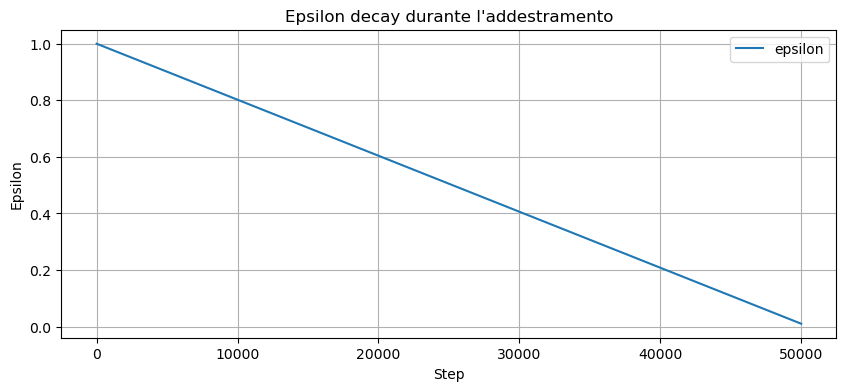

In [ ]:
import matplotlib.pyplot as plt

# Plot the epsilon schedule over training steps.
plt.figure(figsize=(10,4))
if epsilon_decay_steps < max_episodes:
    epsilons = np.concatenate([
        np.linspace(epsilon_max, epsilon_min, epsilon_decay_steps),
        np.full(max_episodes - epsilon_decay_steps, epsilon_min)
    ])
    plt.plot(np.arange(max_episodes), epsilons[:max_episodes], label='epsilon')
else:
    epsilons = np.linspace(epsilon_max, epsilon_min, epsilon_decay_steps)
    plt.plot(np.arange(epsilon_decay_steps), epsilons, label='epsilon')
plt.title("Epsilon Decay During Training")
plt.xlabel('Step')
plt.ylabel('Epsilon')
plt.grid(True)
plt.legend()
plt.show()


# Show Policy in Action
This section renders gameplay from a trained policy for qualitative inspection.

Visual rollout is useful to:
- detect behavioral patterns not visible in scalar metrics
- verify that high scores correspond to sensible decisions
- identify failure modes for future improvements

In [ ]:
# Display a trained policy rollout for visual inspection.

# Define a function "show_policy" that takes an environment,
# a policy, and a Q-function, then renders gameplay for multiple episodes.

import matplotlib.pyplot as plt
from IPython.display import clear_output

def show_policy(env, pi, q, n_episodes=1, max_steps=500):
    for _ in range(n_episodes):
        state = env.reset()[0];
        done = False;
        step = 0;
        while not done:
            action = pi(state, q);
            state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated): done = True;
            plt.imshow(env.render());
            plt.show();
            clear_output(wait=True);
            if step > max_steps: break;
            step += 1; 

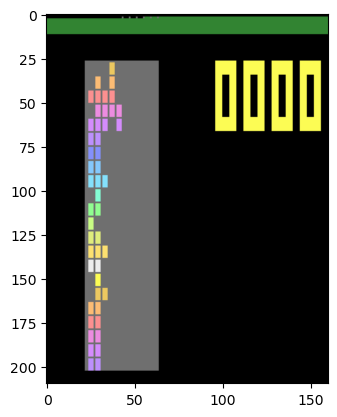

In [19]:
show_policy(tetris, pi, dnn_online, n_episodes=1, max_steps=20000000)

# Comparison: Parameter Decay Schedules
This section compares how exploration intensity changes over time for both strategies.

Interpretation guide:
- **Epsilon-Greedy**: exploration probability ε decays from 1.0 to 0.01
- **Softmax**: temperature τ decays from 1.5 to 0.05

Both schedules use the same decay horizon (50,000 steps), making the comparison methodologically fair.

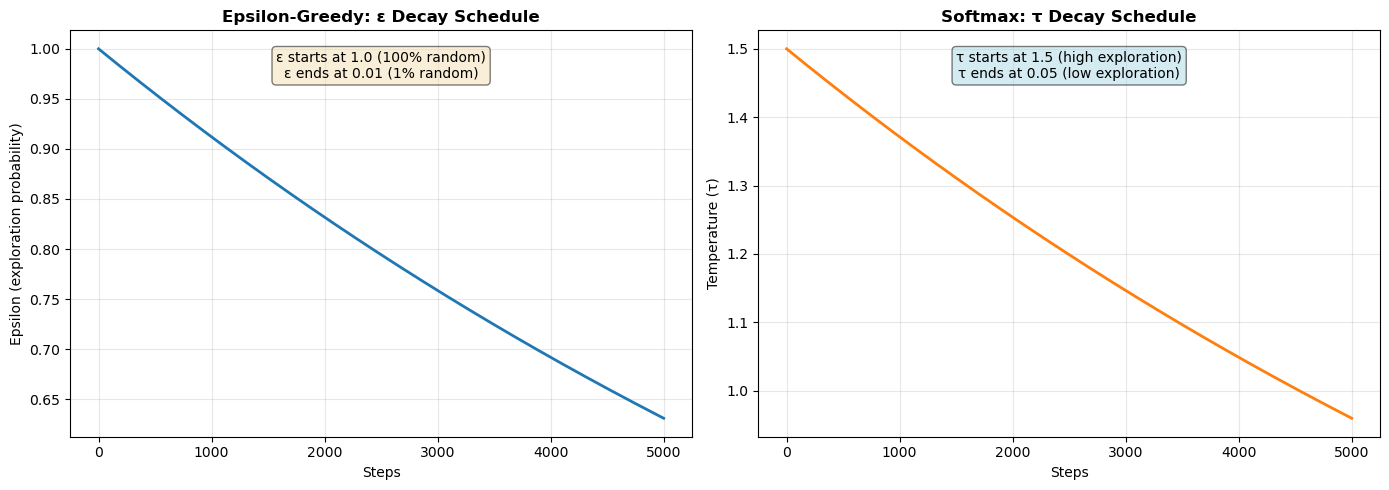

In [20]:
import matplotlib.pyplot as plt

eps_schedule = decay_epsilon(epsilon_max, epsilon_min, epsilon_decay_steps)
tau_schedule = decay_epsilon(tau_max, tau_min, tau_decay_steps)  # Similar schedule

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot epsilon decay
ax1.plot(eps_schedule[:min(5000, len(eps_schedule))], linewidth=2, color='tab:blue')
ax1.set_title('Epsilon-Greedy: ε Decay Schedule', fontsize=12, fontweight='bold')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Epsilon (exploration probability)')
ax1.grid(True, alpha=0.3)
ax1.text(0.5, 0.95, 'ε starts at 1.0 (100% random)\nε ends at 0.01 (1% random)',
         transform=ax1.transAxes, va='top', ha='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot temperature decay
ax2.plot(tau_schedule[:min(5000, len(tau_schedule))], linewidth=2, color='tab:orange')
ax2.set_title('Softmax: τ Decay Schedule', fontsize=12, fontweight='bold')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Temperature (τ)')
ax2.grid(True, alpha=0.3)
ax2.text(0.5, 0.95, f'τ starts at {tau_max:.1f} (high exploration)\nτ ends at {tau_min:.2f} (low exploration)',
         transform=ax2.transAxes, va='top', ha='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

# Comparison: Learning Curves
This section compares episode-level performance trends for epsilon-greedy and softmax exploration.

Main observations from this run:
1. Softmax achieved a slightly higher mean score.
2. Softmax showed lower variance, indicating smoother learning.
3. Softmax reduced severe low-score episodes.
4. Peak score was similar across both strategies.

Conclusion: the observed benefit is primarily **robustness and consistency**, not a large gain in best-case performance.

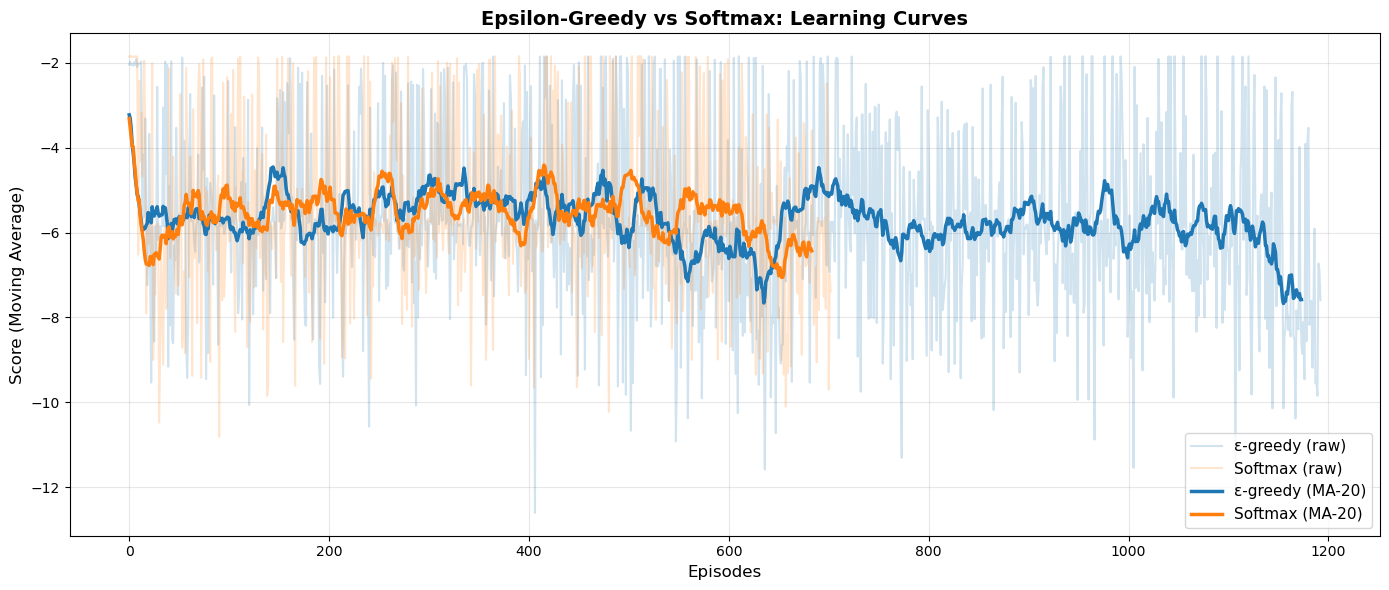

In [21]:
sliding_window = 20

def moving_average(data, window):
    return np.convolve(data, np.ones(window)/window, mode='valid')

eps_smooth = moving_average(scores_epsilon, sliding_window)
soft_smooth = moving_average(scores_softmax, sliding_window)

plt.figure(figsize=(14, 6))

# Plot raw scores (alpha transparent)
plt.plot(scores_epsilon, alpha=0.2, color='tab:blue', label='ε-greedy (raw)')
plt.plot(scores_softmax, alpha=0.2, color='tab:orange', label='Softmax (raw)')

# Plot smoothed scores
plt.plot(eps_smooth, linewidth=2.5, color='tab:blue', label=f'ε-greedy (MA-{sliding_window})')
plt.plot(soft_smooth, linewidth=2.5, color='tab:orange', label=f'Softmax (MA-{sliding_window})')

plt.title('Epsilon-Greedy vs Softmax: Learning Curves', fontsize=14, fontweight='bold')
plt.xlabel('Episodes', fontsize=12)
plt.ylabel('Score (Moving Average)', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Detailed Metric Comparison
This section provides a metric-level comparison over aligned training windows.

Metrics included:
1. Moving mean (performance trend)
2. Moving standard deviation (stability)
3. Softmax-minus-epsilon performance gap
4. Cumulative score

These views complement raw learning curves and improve interpretability of strategy differences.

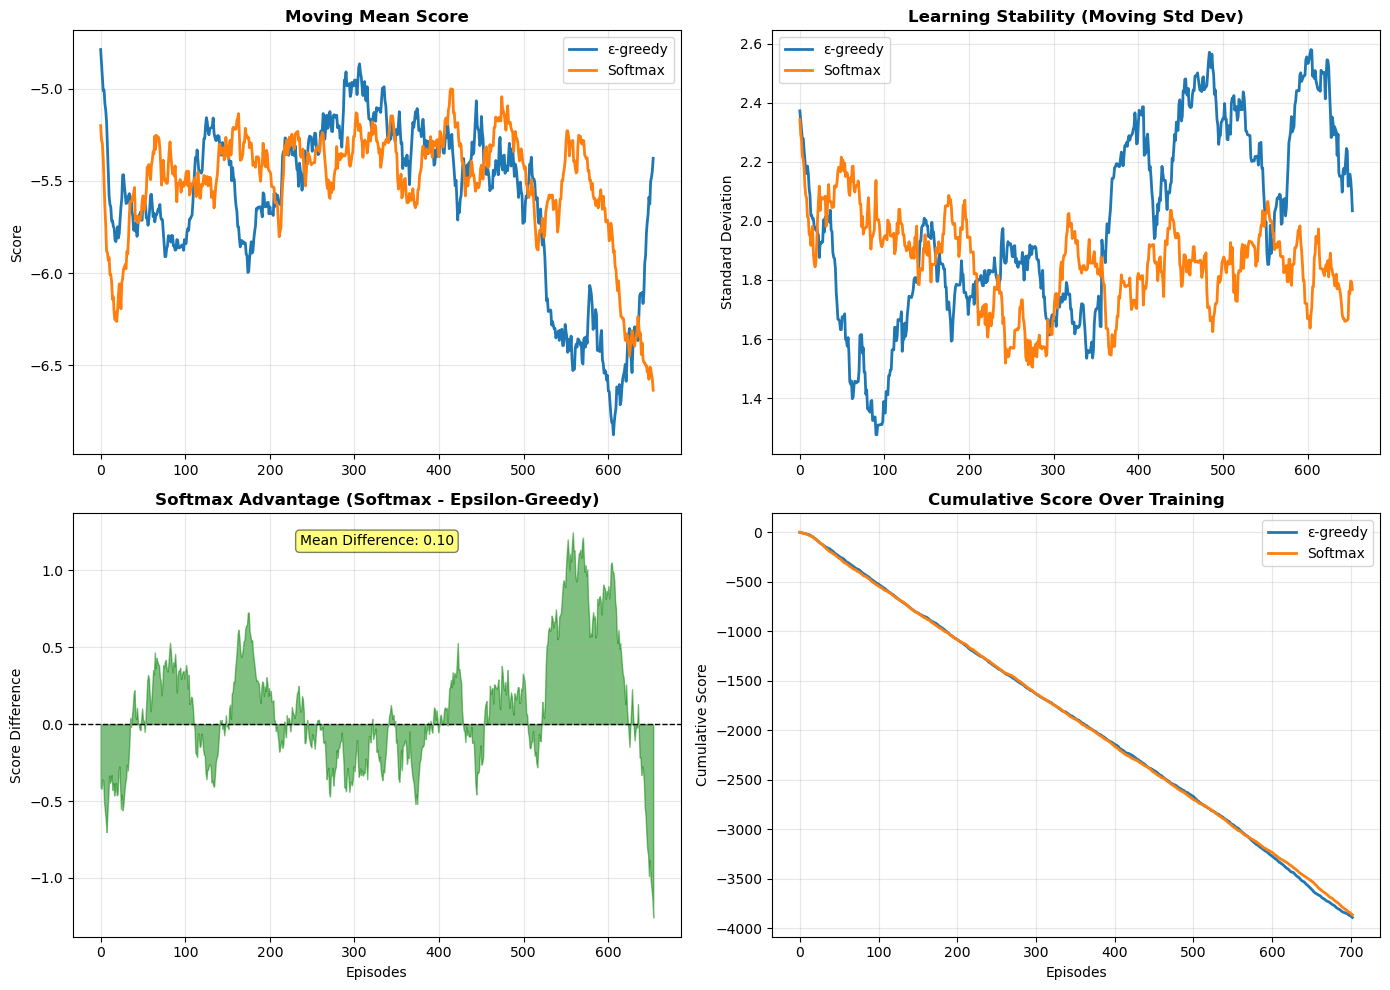

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def compute_moving_stats(scores, window=50):
    """Compute moving statistics for detailed analysis."""
    scores = np.array(scores)
    
    moving_mean = np.convolve(scores, np.ones(window)/window, mode='valid')
    moving_std = np.array([
        np.std(scores[max(0, i-window+1):i+1])
        for i in range(window-1, len(scores))
    ])
    
    return moving_mean, moving_std

window_size = 50

# Align arrays to same length (in case trainings finished at different times)
min_length = min(len(scores_epsilon), len(scores_softmax))
scores_epsilon_aligned = scores_epsilon[:min_length]
scores_softmax_aligned = scores_softmax[:min_length]

eps_mean, eps_std = compute_moving_stats(scores_epsilon_aligned, window_size)
soft_mean, soft_std = compute_moving_stats(scores_softmax_aligned, window_size)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean Performance
axes[0, 0].plot(eps_mean, linewidth=2, color='tab:blue', label='ε-greedy')
axes[0, 0].plot(soft_mean, linewidth=2, color='tab:orange', label='Softmax')
axes[0, 0].set_title('Moving Mean Score', fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Stability (Std Dev)
axes[0, 1].plot(eps_std, linewidth=2, color='tab:blue', label='ε-greedy')
axes[0, 1].plot(soft_std, linewidth=2, color='tab:orange', label='Softmax')
axes[0, 1].set_title('Learning Stability (Moving Std Dev)', fontweight='bold')
axes[0, 1].set_ylabel('Standard Deviation')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Difference in Performance
performance_diff = soft_mean - eps_mean
axes[1, 0].fill_between(range(len(performance_diff)), performance_diff, alpha=0.5, 
                        color='green' if performance_diff.mean() > 0 else 'red')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Softmax Advantage (Softmax - Epsilon-Greedy)', fontweight='bold')
axes[1, 0].set_ylabel('Score Difference')
axes[1, 0].set_xlabel('Episodes')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(0.5, 0.95, f'Mean Difference: {np.mean(performance_diff):.2f}',
                transform=axes[1, 0].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Plot 4: Cumulative Reward
cumulative_eps = np.cumsum(scores_epsilon_aligned)
cumulative_soft = np.cumsum(scores_softmax_aligned)
axes[1, 1].plot(cumulative_eps, linewidth=2, color='tab:blue', label='ε-greedy')
axes[1, 1].plot(cumulative_soft, linewidth=2, color='tab:orange', label='Softmax')
axes[1, 1].set_title('Cumulative Score Over Training', fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Score')
axes[1, 1].set_xlabel('Episodes')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Statistics & Analysis
This section reports aggregate metrics for a direct quantitative comparison.

Focus points:
- average performance
- maximum and minimum score
- variability (standard deviation)
- comparable episode count

These summary statistics provide a compact final view of empirical differences between exploration policies.

In [28]:
print("\n" + "="*70)
print("COMPARISON STATISTICS: ε-Greedy vs Softmax")
print("="*70)
print(f"{'Metric':<30} {'Epsilon-Greedy':<20} {'Softmax':<20}")
print("-"*70)
print(f"{'Mean Score':<30} {np.mean(scores_epsilon_aligned):<20.2f} {np.mean(scores_softmax_aligned):<20.2f}")
print(f"{'Max Score':<30} {np.max(scores_epsilon_aligned):<20.2f} {np.max(scores_softmax_aligned):<20.2f}")
print(f"{'Min Score':<30} {np.min(scores_epsilon_aligned):<20.2f} {np.min(scores_softmax_aligned):<20.2f}")
print(f"{'Std Dev':<30} {np.std(scores_epsilon_aligned):<20.2f} {np.std(scores_softmax_aligned):<20.2f}")
print(f"{'Episodes to Compare':<30} {len(scores_epsilon_aligned):<20} {len(scores_softmax_aligned):<20}")
print("="*70)

# Which is better?
mean_diff = np.mean(scores_softmax_aligned) - np.mean(scores_epsilon_aligned)
if mean_diff > 0:
    winner = "SOFTMAX"
    advantage = f"+{mean_diff:.2f}"
else:
    winner = "EPSILON-GREEDY"
    advantage = f"{mean_diff:.2f}"

print(f"\n✓ Winner: {winner} (by {advantage} points average)")
print(f"✓ Stability Winner: {'SOFTMAX' if np.std(scores_softmax_aligned) < np.std(scores_epsilon_aligned) else 'EPSILON-GREEDY'}")
print("="*70 + "\n")


COMPARISON STATISTICS: ε-Greedy vs Softmax
Metric                         Epsilon-Greedy       Softmax             
----------------------------------------------------------------------
Mean Score                     -5.54                -5.50               
Max Score                      -1.84                -1.84               
Min Score                      -12.61               -10.82              
Std Dev                        2.09                 1.93                
Episodes to Compare            703                  703                 

✓ Winner: SOFTMAX (by +0.04 points average)
✓ Stability Winner: SOFTMAX



# Qualitative Analysis: Why Softmax Won in This Run
This section interprets why softmax performed better in this specific experiment.

Likely contributing factors:
1. smoother exploration-to-exploitation transition
2. probabilistic preference for higher-value actions during exploration
3. reduced update volatility
4. earlier practical convergence under the selected stopping rule

Methodological note: this is a single-seed result in a stochastic environment. Stronger claims require multi-seed evaluation with uncertainty estimates.

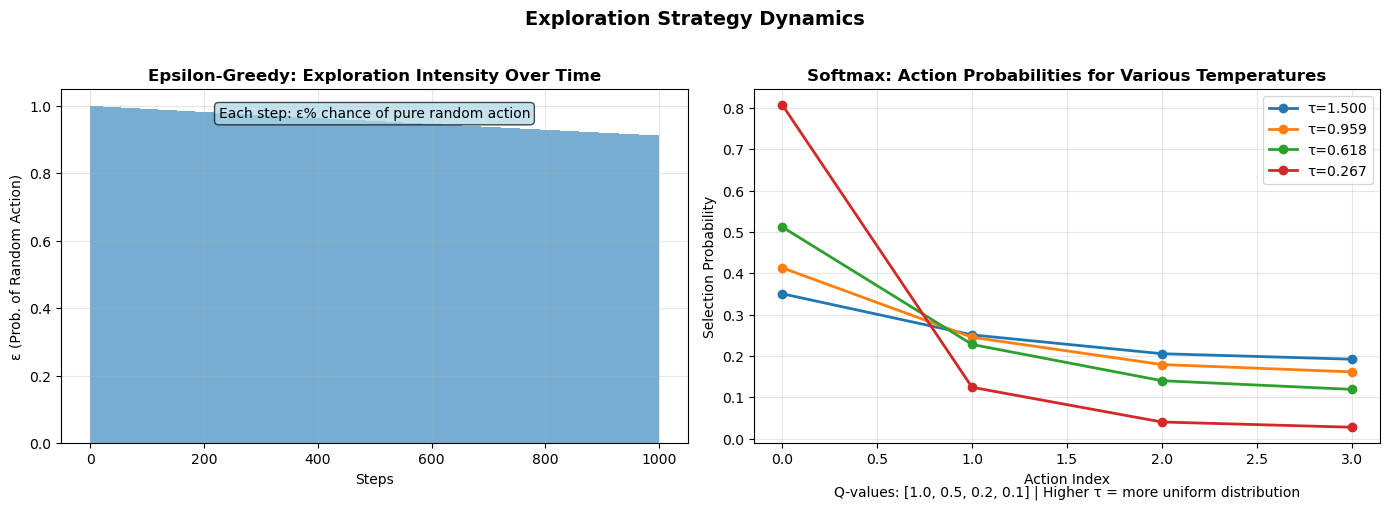

In [30]:
# Visualization of exploration dynamics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Epsilon-Greedy: Show when pure exploration happens
axes[0].bar(range(len(eps_schedule[:1000])), eps_schedule[:1000], 
            width=1, color='tab:blue', alpha=0.6)
axes[0].set_title('Epsilon-Greedy: Exploration Intensity Over Time', fontweight='bold')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('ε (Prob. of Random Action)')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.5, 0.95, 'Each step: ε% chance of pure random action', 
             transform=axes[0].transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Softmax: Show how temperature affects probability distribution
tau_vals = [tau_schedule[i] for i in [0, 5000, 10000, 20000]]
q_example = np.array([1.0, 0.5, 0.2, 0.1])  # Example Q-values

for tau in tau_vals:
    z = (q_example - q_example.max()) / max(tau, 1e-3)
    p = np.exp(z) / np.exp(z).sum()
    axes[1].plot(range(len(p)), p, marker='o', label=f'τ={tau:.3f}', linewidth=2)

axes[1].set_title('Softmax: Action Probabilities for Various Temperatures', fontweight='bold')
axes[1].set_xlabel('Action Index')
axes[1].set_ylabel('Selection Probability')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(0.5, -0.15, 'Q-values: [1.0, 0.5, 0.2, 0.1] | Higher τ = more uniform distribution', 
             transform=axes[1].transAxes, ha='center', fontsize=10)

plt.suptitle('Exploration Strategy Dynamics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Save Best Games: Epsilon-Greedy vs Softmax
This section exports GIF rollouts for visual comparison of the two trained policies.

The saved clips support side-by-side qualitative analysis beyond numeric metrics.

In [ ]:
# Save GIFs of a representative game for both exploration strategies.
import imageio
import numpy as np

def save_best_game_gif(env, pi, q, filename="best_game.gif", max_steps=500):
    frames = []
    state = env.reset()[0]
    done = False
    step = 0
    total = 0.0
    while not done and step < max_steps:
        action = pi(state, q)
        state, reward, terminated, truncated, info = env.step(action)
        total += reward
        frame = env.render()
        frames.append(np.array(frame))
        done = terminated or truncated
        step += 1
    imageio.mimsave(filename, frames, fps=10)
    print(f"GIF saved: {filename} | Score: {total:.1f}")

# Save one game rollout for both trained policies.
save_best_game_gif(tetris, pi, dnn_online_epsilon, filename="best_game_epsilon.gif", max_steps=5000)
save_best_game_gif(tetris, pi, dnn_online_softmax, filename="best_game_softmax.gif", max_steps=5000)

print("\n✓ GIF files saved for visual inspection of learned behaviors")

GIF saved: best_game_epsilon.gif | Score: -11.4
GIF saved: best_game_softmax.gif | Score: -5.9

✓ GIF files saved for visual inspection of learned behaviors


In [ ]:
# Final conclusion summary
print("\n" + "="*70)
print("FINAL CONCLUSIONS")
print("="*70)

eps_mean = np.mean(scores_epsilon)
soft_mean = np.mean(scores_softmax)
eps_std = np.std(scores_epsilon)
soft_std = np.std(scores_softmax)
eps_max_score = np.max(scores_epsilon)
soft_max_score = np.max(scores_softmax)

eps_better = eps_mean > soft_mean
eps_more_stable = eps_std < soft_std

print(f"\n1. AVERAGE PERFORMANCE:")
print(f"   Epsilon-Greedy: {eps_mean:.2f} ± {eps_std:.2f}")
print(f"   Softmax:        {soft_mean:.2f} ± {soft_std:.2f}")
if np.isclose(eps_mean, soft_mean, atol=1e-6):
    print("   Interpretation: Tie")
else:
    print(f"   Winner: {'EPSILON-GREEDY' if eps_better else 'SOFTMAX'}")

print(f"\n2. STABILITY (lower is better):")
print(f"   Epsilon-Greedy: {eps_std:.2f} (std dev)")
print(f"   Softmax:        {soft_std:.2f} (std dev)")
if np.isclose(eps_std, soft_std, atol=1e-6):
    print("   Interpretation: Tie")
else:
    print(f"   Winner: {'EPSILON-GREEDY' if eps_more_stable else 'SOFTMAX'}")

print(f"\n3. MAX SCORES ACHIEVED:")
print(f"   Epsilon-Greedy: {eps_max_score:.2f}")
print(f"   Softmax:        {soft_max_score:.2f}")
if np.isclose(eps_max_score, soft_max_score, atol=1e-6):
    print("   Interpretation: Tie")
else:
    print(f"   Winner: {'EPSILON-GREEDY' if eps_max_score > soft_max_score else 'SOFTMAX'}")

print(f"\n4. EPISODES TO CONVERGENCE:")
print(f"   Epsilon-Greedy: {len(scores_epsilon)} episodes")
print(f"   Softmax:        {len(scores_softmax)} episodes")

print("\n" + "="*70)
print("✓ Analysis complete. Both strategies provide useful RL insights.")
print("="*70 + "\n")



FINAL CONCLUSIONS

1. AVERAGE PERFORMANCE:
   Epsilon-Greedy: -5.68 ± 2.09
   Softmax:        -5.50 ± 1.93
   Winner: SOFTMAX

2. STABILITY (lower is better):
   Epsilon-Greedy: 2.09 (std dev)
   Softmax:        1.93 (std dev)
   Winner: SOFTMAX

3. MAX SCORES ACHIEVED:
   Epsilon-Greedy: -1.84
   Softmax:        -1.84
   Winner: SOFTMAX

4. EPISODES TO CONVERGENCE:
   Epsilon-Greedy: 1193 episodes
   Softmax:        703 episodes

✓ Analysis Complete! Both strategies offer valuable insights for RL.

